In [135]:
import pandas as pd
import numpy as np

params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (14, 10),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large',
         }

plt.rcParams.update(params)

path = "/scratch_hdd/akalinow/Zajecia/2026-2027/Zima/Introduction_to_Experimental_Particle_Physics_I/plots/"

## Pion-proton elastic cross section

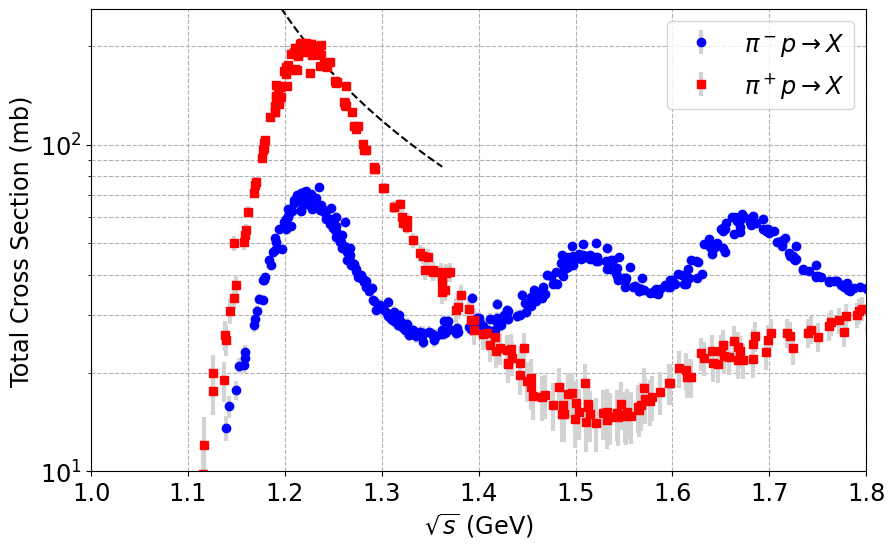

In [136]:
colspecs = [
    (0, 5),       # POINT_NUMBER: I5
    (6, 17),      # PLAB(GEV/C): F11.5
    (17, 28),     # PLAB_MIN: F11.5
    (28, 39),     # PLAB_MAX: F11.5
    (39, 50),     # SIG(MB): F11.5
    (50, 58),     # STA_ERR+: F8.4
    (58, 66),     # STA_ERR-: F8.4
    (67, 73),     # SY_ER+(PCT): F6.1
    (73, 79),     # SY_ER-(PCT): F6.1
    (79, None),   # REFERENCE FLAG: A
 ]
pipp_colspecs = [
    (0, 5),       # POINT_NUMBER: I5
    (6, 17),     # PLAB(GEV/C): F11.5
    (17, 28),    # PLAB_MIN: F11.5
    (28, 39),    # PLAB_MAX: F11.5
    (39, 57),    # SIG(MB): shifted field
    (57, 65),    # STA_ERR+: F8.4
    (65, 76),    # STA_ERR-: F8.4
    (76, 81),    # SY_ER+(PCT): F6.1
    (81, 86),    # SY_ER-(PCT): F6.1
    (86, None),  # REFERENCE FLAG: A
 ]
skiprows = [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11]
usecols = [1, 4, 5]

df_pimp = pd.read_fwf(
    path + 'rpp2022-pimp_total.dat',
    colspecs=colspecs,
    skiprows=skiprows,
    usecols=usecols,
    header=0,
    dtype=float
)
df_pimp = df_pimp.iloc[:400].astype(float)
df_pimp.columns = ['PLAB(GEV/C)', 'SIG(MB)', 'STA_ERR+']
df_pimp['SQRT_S'] = np.sqrt(2 * m_proton * np.sqrt(df_pimp['PLAB(GEV/C)']**2 + m_pion**2) + m_pion**2 + m_proton**2)

df_pipp = pd.read_fwf(
    path + 'rpp2022-pipp_total.dat',
    colspecs=pipp_colspecs,
    skiprows=skiprows,
    usecols=usecols,
)
df_pipp = df_pipp.iloc[:400].astype(float)
df_pipp.columns = ['PLAB(GEV/C)', 'SIG(MB)', 'STA_ERR+']
df_pipp['SQRT_S'] = np.sqrt(2 * m_proton * np.sqrt(df_pipp['PLAB(GEV/C)']**2 + m_pion**2) + m_pion**2 + m_proton**2)

plt.figure(figsize=(10, 6))
plt.errorbar(df_pimp['SQRT_S'], df_pimp['SIG(MB)'], yerr=df_pimp['STA_ERR+'].std(), fmt='o', label=r'$\pi^- p \to X$', color='blue', ecolor='lightgray', elinewidth=3, capsize=0)
plt.errorbar(df_pipp['SQRT_S'], df_pipp['SIG(MB)'], yerr=df_pipp['STA_ERR+'].std(), fmt='s', label=r'$\pi^+ p \to X$', color='red', ecolor='lightgray', elinewidth=3, capsize=0)
plt.ylabel('Total Cross Section (mb)')
plt.xlabel(r'$\sqrt{s}$ (GeV)')
plt.yscale('log')
plt.xlim(1.0, 1.8)
plt.ylim(10, 260)
plt.grid(True, which="both", ls="--")
plt.legend();

#plot maximum cross section from 

p_lab = np.arange(0.1, 0.5, 0.01)
sqrt_s = np.sqrt(2 * m_proton * np.sqrt(p_lab**2 + m_pion**2) + m_pion**2 + m_proton**2)
p_cms = p_lab*m_proton/sqrt_s
k = hbarc/p_cms ## fm
y = 4*np.pi*k**2*(3/2*2+1)/(1/2*2+1)*(0*2+1) #fm**2
y *= 10 # fm**2 to mb
plt.plot(sqrt_s, y, label=r'$\sigma_{max}$', color='black', linestyle='--');